In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

print(tf.__version__)

2.12.0


In [2]:
data_dir = "PlantVillage"   

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset="training"
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset="validation"
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [3]:
from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings('ignore')

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

In [4]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
517/517 [==============================] - 1079s 2s/step - loss: 1.1793 - accuracy: 0.6166 - val_loss: 0.8498 - val_accuracy: 0.7062
Epoch 2/5
517/517 [==============================] - 1032s 2s/step - loss: 0.4708 - accuracy: 0.8422 - val_loss: 0.3835 - val_accuracy: 0.8700
Epoch 3/5
517/517 [==============================] - 1775s 3s/step - loss: 0.2719 - accuracy: 0.9096 - val_loss: 0.4304 - val_accuracy: 0.8583
Epoch 4/5
517/517 [==============================] - 1016s 2s/step - loss: 0.1666 - accuracy: 0.9440 - val_loss: 0.4442 - val_accuracy: 0.8697
Epoch 5/5
517/517 [==============================] - 943s 2s/step - loss: 0.1201 - accuracy: 0.9602 - val_loss: 0.3731 - val_accuracy: 0.8894


In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [7]:
# Reset generator (important)
val_data.reset()

# Get predictions
pred = model.predict(val_data)

# Convert to class index
y_pred = np.argmax(pred, axis=1)

# True labels
y_true = val_data.classes

129/129 [==============================] - 55s 428ms/step


In [8]:
class_labels = list(val_data.class_indices.keys())

In [9]:
val_data = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset="validation",
    shuffle=False   # 🔥 IMPORTANT
)

Found 4122 images belonging to 15 classes.


In [10]:
val_data.reset()

pred = model.predict(val_data)
y_pred = np.argmax(pred, axis=1)
y_true = val_data.classes

129/129 [==============================] - 55s 426ms/step


In [11]:
print(classification_report(y_true, y_pred, target_names=class_labels))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.90      0.89      0.89       199
                     Pepper__bell___healthy       0.96      0.94      0.95       295
                      Potato___Early_blight       0.89      0.92      0.91       200
                       Potato___Late_blight       0.88      0.82      0.85       200
                           Potato___healthy       1.00      0.53      0.70        30
                      Tomato_Bacterial_spot       0.89      0.97      0.93       425
                        Tomato_Early_blight       0.64      0.81      0.71       200
                         Tomato_Late_blight       0.88      0.81      0.84       381
                           Tomato_Leaf_Mold       0.79      0.94      0.86       190
                  Tomato_Septoria_leaf_spot       0.89      0.76      0.82       354
Tomato_Spider_mites_Two_spotted_spider_mite       0.89      0.91

In [12]:
cm = confusion_matrix(y_true, y_pred)
print("📊 Confusion Matrix:\n")
print(cm)

📊 Confusion Matrix:

[[177   6   2   2   0   0   3   2   0   7   0   0   0   0   0]
 [  9 277   3   0   0   0   1   1   1   3   0   0   0   0   0]
 [  2   0 184   2   0   0   2   9   0   1   0   0   0   0   0]
 [  1   0   5 164   0   0  10  13   0   2   3   0   1   0   1]
 [  1   3   0   4  16   0   0   0   1   1   0   4   0   0   0]
 [  0   0   0   0   0 411   9   3   0   0   0   0   2   0   0]
 [  0   0   2   1   0   7 162   8   3   1   2   8   4   1   1]
 [  3   0   4   7   0   1  37 307  11   7   1   0   2   0   1]
 [  0   0   0   0   0   0   3   1 178   4   2   0   1   0   1]
 [  3   1   6   5   0   7  19   2  25 269   3   8   0   4   2]
 [  0   1   0   1   0   0   3   0   1   2 306  17   0   3   1]
 [  0   0   0   0   0   2   4   0   3   3  23 236   1   3   5]
 [  1   0   0   1   0  33   2   3   0   0   2   0 599   0   0]
 [  0   0   0   0   0   0   0   0   3   1   1   1   1  67   0]
 [  0   0   0   0   0   0   0   0   0   1   0   4   0   0 313]]


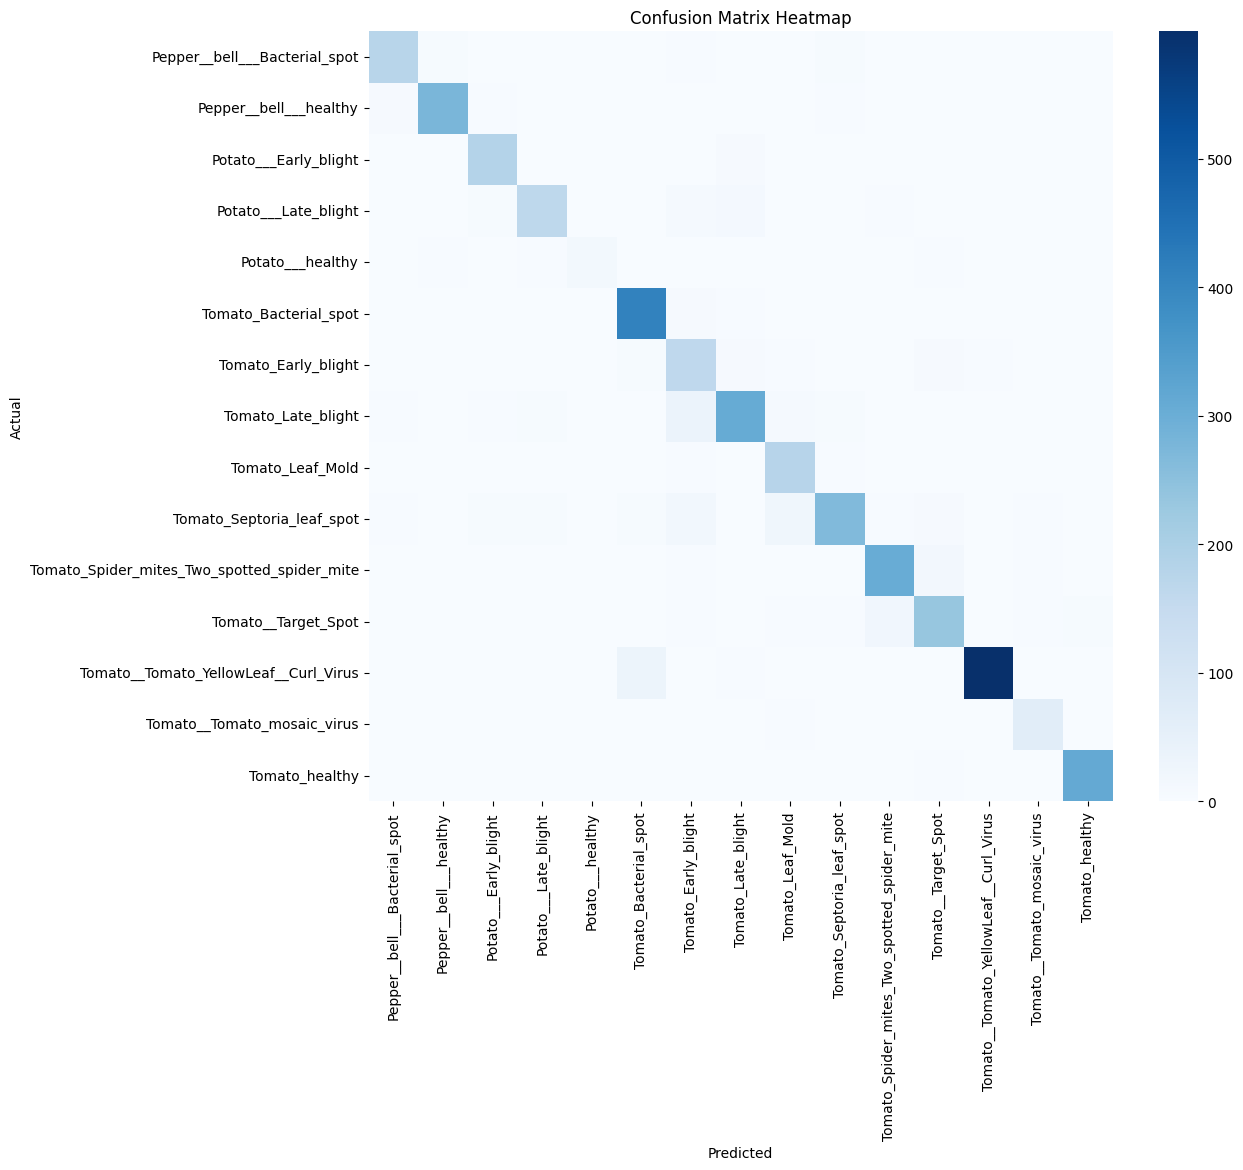

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [14]:
model.save("plant_model.h5")

In [15]:
import json

with open("classes.json", "w") as f:
    json.dump(train_data.class_indices, f)

In [16]:
img_path =r"C:\Users\WINDOWS\Downloads\project\PlantVillage\Tomato_healthy\0a0d6a11-ddd6-4dac-8469-d5f65af5afca___RS_HL 0555.JPG"

In [17]:
import numpy as np
import cv2
import json

# Load image
img_path =r"C:\Users\WINDOWS\Downloads\project\PlantVillage\Tomato_healthy\0a0d6a11-ddd6-4dac-8469-d5f65af5afca___RS_HL 0555.JPG"   # ✅ correct

img = cv2.imread(img_path)

# Check if image loaded
if img is None:
    print("❌ Image not found. Check file name!")
else:
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = np.reshape(img, (1,224,224,3))

    # Predict
    prediction = model.predict(img)
    class_index = np.argmax(prediction)

    # Load class names
    with open("classes.json", "r") as f:
        class_names = json.load(f)

    class_names = {v:k for k,v in class_names.items()}

    print("🌿 Prediction:", class_names[class_index])

1/1 [==============================] - 0s 113ms/step
🌿 Prediction: Tomato_Early_blight


In [18]:
model.save("plant_model.keras")